# 01: 1層/2層FCネットワークで見る紹介先診断士の選定

このNotebookでは、画像診断依頼が届いたときに、提携診断士のうち誰へ紹介するかを予測する小さなモデルを作ります。

講義では、最初に「依頼特徴量と診断士特徴量を横に並べただけの入力」を作り、同じニューラルネットワークを各診断士候補へ適用します。そのうえで、1層FCでは候補の平均的な強さに寄りやすく、2層FCでは「依頼の条件 × 診断士の特徴」の組み合わせを拾いやすくなることを順番に確認します。


## このNotebookで扱うデータとモデル

- `01/data/diagnostician_routing/doctor_master.csv`: 診断士候補6名の特徴量
- `01/data/diagnostician_routing/routing_requests.csv`: 画像診断依頼1800件と、教材用の教師ラベル `selected_doctor_id`

このNotebookの候補診断士は `D1`〜`D6` の6名だけです。各依頼について、この6名のうち誰がCSV上の教師ラベルになっているかを学習します。

重要: `selected_doctor_id` は教材用CSVに用意した教師ラベルです。実運用で医学的・業務的に最適だった診断士を検証した結果ではありません。モデルは、CSVに入っているラベルと依頼条件・診断士特徴の対応関係を学習します。ここでいう `accuracy` も、医学的正解率ではなく「予測1位がCSVラベルと一致した割合」です。

教材CSVの教師ラベルは、CSV作成時に同じ判断軸を持つ3つの独立判定で `D1`〜`D6` から1名を選び、多数票を採ったものです。3判定が全員別の候補を選んだ場合だけ、依頼内容と候補特徴を表で説明しやすい1名を採っています。判断軸は、画像種別、部位、枚数規模、優先度、速さ、負荷です。スライス厚、施設の月間件数、過去レポート有無などの補助列はラベル判断には使いません。

入力は2種類あります。

1. **依頼側特徴量**
   - 画像種別
   - 部位
   - 枚数規模
   - 優先度
   - スライス厚
   - 施設の月間件数
   - 過去レポート有無

2. **診断士側特徴量**
   - 得意画像
   - 得意部位
   - 大量対応
   - 速さ
   - 負荷
   - 専門年数
   - 直近品質スコア
   - 月間シフト枠

各候補診断士について、同じニューラルネットワークに次の入力を渡します。

```text
[依頼特徴量, 診断士jの特徴量] -> score_j
```

全診断士の `score_j` をsoftmaxで確率に変換し、最も確率が高い候補を紹介先として予測します。ここではペア特徴量は作らず、入力はあくまで `[依頼特徴量, 診断士特徴量]` の結合だけにします。

In [13]:
# Notebook全体で使うライブラリだけを読み込みます。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string(index=False))
        else:
            print(obj)


In [14]:
from pathlib import Path

DATA_DIR_CANDIDATES = [
    Path("data/diagnostician_routing"),
    Path("01/data/diagnostician_routing"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "data/diagnostician_routing が見つかりません。"
        "ai-engineering/beginners-guide または ai-engineering/beginners-guide/01 からNotebookを開いてください。"
    )

doctor_master = pd.read_csv(DATA_DIR / "doctor_master.csv")
request_table = pd.read_csv(DATA_DIR / "routing_requests.csv")

# one-hot化で列の並びを固定するため、カテゴリの順序を明示します。
IMAGE_TYPES = ["CT", "MRI", "X線", "超音波"]
BODY_PARTS = ["頭部", "胸部", "腹部", "脊椎", "四肢"]
IMAGE_COUNT_RANGES = ["少量", "中量", "大量"]
PRIORITY_LEVELS = ["通常", "当日", "夜間"]
SPEED_LEVELS = ["速い", "標準", "ゆっくり"]
LOAD_LEVELS = ["低", "中", "高"]

REQUEST_AUXILIARY_COLUMNS = ["scanner_slice_thickness_mm", "facility_monthly_cases", "prior_report_available"]
DOCTOR_AUXILIARY_COLUMNS = ["subspecialty_years", "recent_quality_score", "monthly_shift_slots"]
EXPECTED_REQUEST_COLUMNS = [
    "request_id",
    "image_type",
    "body_part",
    "image_count_range",
    "priority_level",
    *REQUEST_AUXILIARY_COLUMNS,
    "selected_doctor_id",
]
EXPECTED_DOCTOR_COLUMNS = [
    "doctor_id",
    "preferred_image_type",
    "preferred_body_part",
    "large_case_ready",
    "speed_level",
    "load_level",
    *DOCTOR_AUXILIARY_COLUMNS,
]
NUM_DOCTORS = len(doctor_master)

print(f"診断士候補数: {NUM_DOCTORS}名")
print("候補診断士ID:", ", ".join(doctor_master["doctor_id"]))
print("診断士マスタ D1〜D6")
display(doctor_master)
print("依頼データ")
display(request_table.head())

診断士候補数: 6名
候補診断士ID: D1, D2, D3, D4, D5, D6
診断士マスタ D1〜D6


,doctor_id,preferred_image_type,preferred_body_part,large_case_ready,speed_level,load_level,subspecialty_years,recent_quality_score,monthly_shift_slots
0,D1,CT,頭部,0,速い,中,12,0.91,10
1,D2,MRI,脊椎,0,標準,低,15,0.94,8
2,D3,CT,胸部,1,速い,高,9,0.88,14
3,D4,X線,四肢,0,標準,低,7,0.90,6
4,D5,MRI,腹部,1,標準,中,18,0.96,9
5,D6,超音波,腹部,1,速い,低,11,0.93,12


依頼データ


,request_id,image_type,body_part,image_count_range,priority_level,scanner_slice_thickness_mm,facility_monthly_cases,prior_report_available,selected_doctor_id
0,R0001,X線,四肢,大量,当日,0.9,431,0,D4
1,R0002,CT,胸部,中量,通常,0.6,110,0,D3
2,R0003,CT,頭部,少量,通常,1.1,177,0,D1
3,R0004,MRI,脊椎,少量,通常,0.7,177,1,D2
4,R0005,X線,四肢,大量,当日,0.9,178,1,D4


In [15]:
# 実装準備: 文字列カテゴリや業務上の値を、ニューラルネットワークに渡せる数値ベクトルへ変換します。
# 講義中は細かい実装より、「依頼側特徴量」と「診断士側特徴量」を別々に作る点を見てください。
def validate_columns(table, expected_columns, table_name):
    actual_columns = table.columns.tolist()
    missing = [column for column in expected_columns if column not in actual_columns]
    extra = [column for column in actual_columns if column not in expected_columns]
    if missing or extra:
        raise ValueError(f"{table_name} の列が想定と違います。missing={missing}, extra={extra}")


def one_hot(ids, size):
    out = np.zeros((len(ids), size), dtype=float)
    out[np.arange(len(ids)), ids] = 1.0
    return out


def ids_from_categories(values, labels, column_name):
    mapping = {label: i for i, label in enumerate(labels)}
    missing = sorted(set(values) - set(mapping))
    if missing:
        raise ValueError(f"{column_name} に未知カテゴリがあります: {missing}")
    return np.array([mapping[v] for v in values], dtype=int)


def build_request_feature_matrix(request_table):
    validate_columns(request_table, EXPECTED_REQUEST_COLUMNS, "routing_requests.csv")
    image_type_id = ids_from_categories(request_table["image_type"], IMAGE_TYPES, "image_type")
    body_part_id = ids_from_categories(request_table["body_part"], BODY_PARTS, "body_part")
    image_count_range_id = ids_from_categories(request_table["image_count_range"], IMAGE_COUNT_RANGES, "image_count_range")
    priority_level_id = ids_from_categories(request_table["priority_level"], PRIORITY_LEVELS, "priority_level")

    scanner_slice_thickness = request_table[["scanner_slice_thickness_mm"]].to_numpy(dtype=float)
    facility_monthly_cases = request_table[["facility_monthly_cases"]].to_numpy(dtype=float)
    prior_report_available = request_table[["prior_report_available"]].to_numpy(dtype=float)

    return np.concatenate([
        one_hot(image_type_id, len(IMAGE_TYPES)),
        one_hot(body_part_id, len(BODY_PARTS)),
        one_hot(image_count_range_id, len(IMAGE_COUNT_RANGES)),
        one_hot(priority_level_id, len(PRIORITY_LEVELS)),
        (scanner_slice_thickness - 0.5) / (5.0 - 0.5),
        facility_monthly_cases / 500.0,
        prior_report_available,
    ], axis=1)


def build_doctor_feature_matrix(doctor_master):
    validate_columns(doctor_master, EXPECTED_DOCTOR_COLUMNS, "doctor_master.csv")
    preferred_image_type_id = ids_from_categories(
        doctor_master["preferred_image_type"], IMAGE_TYPES, "preferred_image_type"
    )
    preferred_body_part_id = ids_from_categories(
        doctor_master["preferred_body_part"], BODY_PARTS, "preferred_body_part"
    )
    speed_level_id = ids_from_categories(doctor_master["speed_level"], SPEED_LEVELS, "speed_level")
    load_level_id = ids_from_categories(doctor_master["load_level"], LOAD_LEVELS, "load_level")

    return np.concatenate([
        one_hot(preferred_image_type_id, len(IMAGE_TYPES)),
        one_hot(preferred_body_part_id, len(BODY_PARTS)),
        doctor_master[["large_case_ready"]].to_numpy(dtype=float),
        one_hot(speed_level_id, len(SPEED_LEVELS)),
        one_hot(load_level_id, len(LOAD_LEVELS)),
        doctor_master[["subspecialty_years"]].to_numpy(dtype=float) / 20.0,
        doctor_master[["recent_quality_score"]].to_numpy(dtype=float),
        doctor_master[["monthly_shift_slots"]].to_numpy(dtype=float) / 20.0,
    ], axis=1)


def build_target_ids(request_table, doctor_master):
    doctor_id_to_index = {doctor_id: i for i, doctor_id in enumerate(doctor_master["doctor_id"])}
    missing = sorted(set(request_table["selected_doctor_id"]) - set(doctor_id_to_index))
    if missing:
        raise ValueError(f"selected_doctor_id に未知の診断士IDがあります: {missing}")
    return np.array([doctor_id_to_index[v] for v in request_table["selected_doctor_id"]], dtype=int)

In [5]:
# ここまでで、依頼1件は「カテゴリ・画像種別・部位・納期・緊急度など」の数値ベクトルに、
# 診断士1名は「対応可否・負荷・得意カテゴリなど」の数値ベクトルに変換しました。
# 次にやりたいのは「この依頼をD1〜D6の誰に渡すのがよさそうか」を比べることです。
# そのため、同じ依頼ベクトルを6回コピーし、D1〜D6それぞれの診断士ベクトルを横に連結します。
# つまり、1件の依頼から [依頼R0001, D1の特徴量] ... [依頼R0001, D6の特徴量] という6候補ぶんの入力を作ります。
def build_candidate_tensor(request_features, doctor_features):
    n = request_features.shape[0]
    repeated_requests = np.repeat(request_features[:, None, :], NUM_DOCTORS, axis=1)
    repeated_doctors = np.repeat(doctor_features[None, :, :], n, axis=0)
    return np.concatenate([repeated_requests, repeated_doctors], axis=2)


request_features = build_request_feature_matrix(request_table)
doctor_features = build_doctor_feature_matrix(doctor_master)
target_ids = build_target_ids(request_table, doctor_master)
target_one_hot = one_hot(target_ids, NUM_DOCTORS)
X = build_candidate_tensor(request_features, doctor_features)

print("X shape =", X.shape, "= [依頼数, 診断士候補数, 特徴量数]")
print("target one-hot shape =", target_one_hot.shape)
print("selected_doctor_id はモデル入力ではなく、loss計算で使うCSV上の教師ラベルです。")
label_preview = request_table[["request_id", "selected_doctor_id"]].head(5).copy()
label_preview["teacher_label_index"] = target_ids[:5]
label_preview["teacher_label_one_hot"] = [target_one_hot[i].astype(int).tolist() for i in range(5)]
display(label_preview)


X shape = (1800, 6, 37) = [依頼数, 診断士候補数, 特徴量数]
target one-hot shape = (1800, 6)
selected_doctor_id はモデル入力ではなく、loss計算で使うCSV上の教師ラベルです。


,request_id,selected_doctor_id,teacher_label_index,teacher_label_one_hot
0,R0001,D4,3,"[0, 0, 0, 1, 0, 0]"
1,R0002,D3,2,"[0, 0, 1, 0, 0, 0]"
2,R0003,D1,0,"[1, 0, 0, 0, 0, 0]"
3,R0004,D2,1,"[0, 1, 0, 0, 0, 0]"
4,R0005,D4,3,"[0, 0, 0, 1, 0, 0]"


In [16]:
# 学習用と確認用を分け、softmax・loss・accuracyを共通関数にします。
# 以降の1層FCと2層FCは、同じデータ分割・同じ評価関数で比べます。
rng = np.random.default_rng(42)
indices = rng.permutation(len(target_ids))
train_idx = indices[:1400]
test_idx = indices[1400:]

X_train, y_train = X[train_idx], target_ids[train_idx]
X_test, y_test = X[test_idx], target_ids[test_idx]


def softmax(scores):
    z = scores - scores.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def cross_entropy(scores, target_ids):
    probs = softmax(scores)
    loss = -np.log(probs[np.arange(len(target_ids)), target_ids] + 1e-9).mean()
    return loss, probs


def accuracy(scores, target_ids):
    return (scores.argmax(axis=1) == target_ids).mean()


def summarize_history(history):
    return pd.DataFrame(history, columns=["epoch", "loss", "accuracy"])


def plot_loss_history(history, title):
    # 表だけでは学習の進み方が見えにくいため、lossが下がる軌跡を線で確認します。
    history_table = summarize_history(history)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_table["epoch"], history_table["loss"], marker="o")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("cross entropy loss")
    ax.grid(True, alpha=0.3)
    plt.show()


## まずは1層FCだけで学習する

最初に、隠れ層を持たない1層FCを学習します。講義ではここで「同じ重みを全候補に適用し、候補ごとのscoreをsoftmaxする」という基本形だけに集中します。


In [17]:
# 1層FCは score = x @ W + b だけのモデルです。
# 構造が単純なので、まずこのモデルで「何ができて、何が弱いか」を確認します。
def train_one_layer_fc(X_train, y_train, epochs=500, lr=0.01):
    n, num_candidates, feature_dim = X_train.shape
    rng = np.random.default_rng(7)
    W = rng.normal(0.0, 0.02, size=feature_dim)
    b = 0.0
    history = []

    for epoch in range(epochs):
        scores = np.tensordot(X_train, W, axes=([2], [0])) + b
        loss, probs = cross_entropy(scores, y_train)

        dscores = probs.copy()
        dscores[np.arange(n), y_train] -= 1.0
        dscores /= n

        dW = (X_train * dscores[:, :, None]).sum(axis=(0, 1))
        db = dscores.sum()

        W -= lr * dW
        b -= lr * db

        if epoch % 20 == 0 or epoch == epochs - 1:
            history.append((epoch, loss, accuracy(scores, y_train)))

    return W, b, history


def predict_one_layer_fc(X, W, b):
    return np.tensordot(X, W, axes=([2], [0])) + b


1層FCの評価


,model,train_loss,train_accuracy,test_loss,test_accuracy
0,1層FC,1.731,0.244,1.74,0.252


1層FCの学習履歴


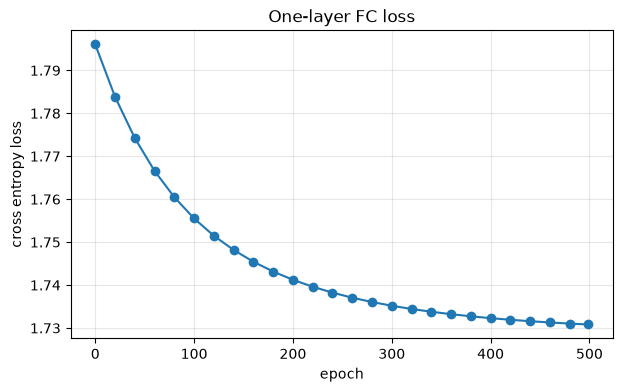

In [18]:
# 1層FCだけを学習し、lossが下がるかを表とグラフの両方で確認します。
# ここでは2層FCはまだ出さず、受講者の注意を1層FCの挙動に絞ります。
W_linear, b_linear, history_linear = train_one_layer_fc(X_train, y_train)

scores_linear_train = predict_one_layer_fc(X_train, W_linear, b_linear)
scores_linear_test = predict_one_layer_fc(X_test, W_linear, b_linear)

linear_result = pd.DataFrame([{
    "model": "1層FC",
    "train_loss": cross_entropy(scores_linear_train, y_train)[0],
    "train_accuracy": accuracy(scores_linear_train, y_train),
    "test_loss": cross_entropy(scores_linear_test, y_test)[0],
    "test_accuracy": accuracy(scores_linear_test, y_test),
}])

print("1層FCの評価")
display(linear_result.round(3))
print("1層FCの学習履歴")
plot_loss_history(history_linear, "One-layer FC loss")

## 1層FCで1件の依頼を判定する

ここからは、CSV上の教師ラベルが `D6` になっている `R1287` を固定して見ます。`R1287` は「超音波 / 腹部 / 大量 / 夜間」の依頼です。

まずは、いま学習した1層FCだけでこの依頼を判定します。2層FCはまだ使いません。後で同じ `R1287` を2層FCでも判定し、同じ入力に対して順位づけがどう変わるかを比べます。

注意点は、入力にはスライス厚、施設の月間件数、過去レポート有無のような補助列も含まれていることです。ただし、教師ラベルの判断軸は画像種別、部位、枚数規模、優先度、速さ、負荷に固定しています。説明表では補助列を出さず、表を見たときに `D6` が自然に見える主要特徴量だけを確認します。

In [19]:
# 実装詳細: R1287の依頼内容に対応する診断士特徴量を、画面共有で読みやすい表に整えます。
def build_candidate_explanation_table(req_index):
    request = request_table.loc[req_index]
    table = doctor_master[[
        "doctor_id",
        "preferred_image_type",
        "preferred_body_part",
        "large_case_ready",
        "speed_level",
        "load_level",
    ]].copy()

    table["画像一致"] = (table["preferred_image_type"] == request["image_type"]).astype(int)
    table["部位一致"] = (table["preferred_body_part"] == request["body_part"]).astype(int)
    table["大量対応適合"] = np.where(
        request["image_count_range"] == "大量",
        table["large_case_ready"].astype(int),
        1,
    )
    table["速さ適合"] = np.where(
        request["priority_level"] in ["当日", "夜間"],
        (table["speed_level"] == "速い").astype(int),
        1,
    )

    return table.rename(columns={
        "preferred_image_type": "得意画像",
        "preferred_body_part": "得意部位",
        "large_case_ready": "大量対応",
        "speed_level": "速さ",
        "load_level": "負荷",
    })


def show_single_request_prediction(title, req_index, scores_for_one_request, probability_col):
    probs = softmax(scores_for_one_request[None, :])[0]
    teacher_label_id = request_table.loc[req_index, "selected_doctor_id"]
    predicted_index = int(probs.argmax())
    predicted_id = doctor_master.loc[predicted_index, "doctor_id"]

    comparison = build_candidate_explanation_table(req_index)
    comparison[probability_col] = np.round(probs, 3)
    comparison["teacher_label"] = (comparison["doctor_id"] == teacher_label_id).astype(int)
    comparison["predicted"] = (comparison["doctor_id"] == predicted_id).astype(int)

    print(title)
    print(f"CSV教師ラベル: {teacher_label_id} / 予測1位: {predicted_id}")
    display(request_table.iloc[[req_index]])
    display(comparison.sort_values(probability_col, ascending=False))
    return {
        "teacher_label_id": teacher_label_id,
        "predicted_id": predicted_id,
        "probabilities": probs,
        "table": comparison,
    }

# ここでは例示する依頼を request_id で固定します。
# データの並び順やtrain/test splitの位置が変わっても、講義中は必ずR1287を見ます。
EXAMPLE_REQUEST_ID = "R1287"
example_matches = request_table.index[request_table["request_id"] == EXAMPLE_REQUEST_ID].tolist()
assert len(example_matches) == 1, f"{EXAMPLE_REQUEST_ID} がCSV内で一意に見つかりません。"
example_request_index = int(example_matches[0])

print("比較に使う依頼")
display(request_table.iloc[[example_request_index]])

# 1層FCでR1287を判定します。
# 1層FCは依頼側特徴量と診断士側特徴量の組み合わせを作れないため、D6に必要な一致条件をまとめて拾えません。
example_scores_linear = predict_one_layer_fc(X[example_request_index:example_request_index + 1], W_linear, b_linear)[0]
linear_example = show_single_request_prediction(
    "1層FCの判定例",
    example_request_index,
    example_scores_linear,
    "p_1layer",
)


比較に使う依頼


,request_id,image_type,body_part,image_count_range,priority_level,scanner_slice_thickness_mm,facility_monthly_cases,prior_report_available,selected_doctor_id
1286,R1287,超音波,腹部,大量,夜間,1.2,286,1,D6


1層FCの判定例
CSV教師ラベル: D6 / 予測1位: D4


,request_id,image_type,body_part,image_count_range,priority_level,scanner_slice_thickness_mm,facility_monthly_cases,prior_report_available,selected_doctor_id
1286,R1287,超音波,腹部,大量,夜間,1.2,286,1,D6


,doctor_id,得意画像,得意部位,大量対応,速さ,負荷,画像一致,部位一致,大量対応適合,速さ適合,p_1layer,teacher_label,predicted
3,D4,X線,四肢,0,標準,低,0,0,0,0,0.243,0,1
0,D1,CT,頭部,0,速い,中,0,0,0,1,0.197,0,0
5,D6,超音波,腹部,1,速い,低,1,1,1,1,0.184,1,0
1,D2,MRI,脊椎,0,標準,低,0,0,0,0,0.170,0,0
2,D3,CT,胸部,1,速い,高,0,0,1,1,0.109,0,0
4,D5,MRI,腹部,1,標準,中,0,1,1,0,0.098,0,0


## 次に2層FCで学習する

1層FCの判定例を確認した後で、隠れ層を1つ追加した2層FCを学習します。ここからは、ReLUを挟むことで「画像種別 × 得意画像」「部位 × 得意部位」「大量画像 × 大量対応」「夜間優先度 × 速い対応」のような組み合わせを表現しやすくなることを見せます。

ここで挙げる組み合わせは単独ルールではありません。例えば「大量画像」だけでD6に決まるわけではなく、画像種別、部位、優先度、速さ、負荷など複数の特徴を同時に見ます。

In [20]:
# 実装詳細: 2層FCを手書きで学習するための関数です。
# 講義の本線では、ReLUを挟むと特徴量の組み合わせを表現しやすくなる点だけ押さえます。
def train_two_layer_fc(X_train, y_train, hidden_dim=48, epochs=600, lr=0.1):
    n, num_candidates, feature_dim = X_train.shape
    rng = np.random.default_rng(1)
    W1 = rng.normal(0.0, 0.08, size=(feature_dim, hidden_dim))
    b1 = np.zeros(hidden_dim)
    W2 = rng.normal(0.0, 0.08, size=hidden_dim)
    b2 = 0.0
    history = []

    for epoch in range(epochs):
        Z1 = X_train @ W1 + b1
        H1 = np.maximum(0.0, Z1)
        scores = H1 @ W2 + b2
        loss, probs = cross_entropy(scores, y_train)

        dscores = probs.copy()
        dscores[np.arange(n), y_train] -= 1.0
        dscores /= n

        dW2 = (H1 * dscores[:, :, None]).sum(axis=(0, 1))
        db2 = dscores.sum()

        dH1 = dscores[:, :, None] * W2
        dZ1 = dH1 * (Z1 > 0.0)
        dW1 = (X_train[:, :, :, None] * dZ1[:, :, None, :]).sum(axis=(0, 1))
        db1 = dZ1.sum(axis=(0, 1))

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % 20 == 0 or epoch == epochs - 1:
            history.append((epoch, loss, accuracy(scores, y_train)))

    return W1, b1, W2, b2, history


def predict_two_layer_fc(X, W1, b1, W2, b2):
    H1 = np.maximum(0.0, X @ W1 + b1)
    return H1 @ W2 + b2

2層FCの評価


,model,train_loss,train_accuracy,test_loss,test_accuracy
0,2層FC,0.054,1.0,0.061,1.0


2層FCの学習履歴


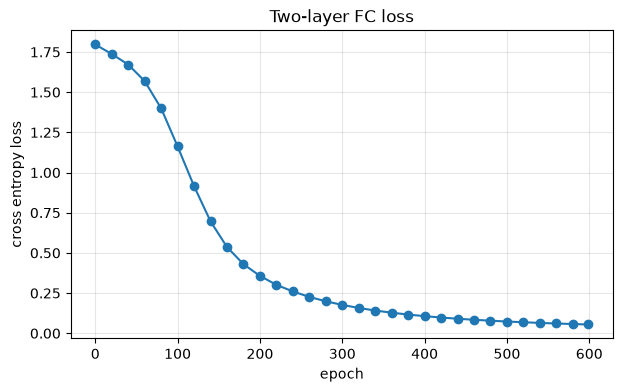

In [21]:
# ここで初めて2層FCを学習します。
# 1層FCと同じ形式で、評価表・学習履歴・lossグラフを並べて確認できるようにします。
W1, b1, W2, b2, history_two_layer = train_two_layer_fc(X_train, y_train)

scores_two_train = predict_two_layer_fc(X_train, W1, b1, W2, b2)
scores_two_test = predict_two_layer_fc(X_test, W1, b1, W2, b2)

two_layer_result = pd.DataFrame([{
    "model": "2層FC",
    "train_loss": cross_entropy(scores_two_train, y_train)[0],
    "train_accuracy": accuracy(scores_two_train, y_train),
    "test_loss": cross_entropy(scores_two_test, y_test)[0],
    "test_accuracy": accuracy(scores_two_test, y_test),
}])

print("2層FCの評価")
display(two_layer_result.round(3))
print("2層FCの学習履歴")
plot_loss_history(history_two_layer, "Two-layer FC loss")

In [22]:
# 1層FCで見たR1287を、2層FCでも判定します。
# 同じ依頼データに対して、2層FCがCSV教師ラベルのD6へ高い確率を付けられるかを確認します。
example_scores_two = predict_two_layer_fc(X[example_request_index:example_request_index + 1], W1, b1, W2, b2)[0]
two_layer_example = show_single_request_prediction(
    "2層FCの判定例",
    example_request_index,
    example_scores_two,
    "p_2layer",
)

2層FCの判定例
CSV教師ラベル: D6 / 予測1位: D6


,request_id,image_type,body_part,image_count_range,priority_level,scanner_slice_thickness_mm,facility_monthly_cases,prior_report_available,selected_doctor_id
1286,R1287,超音波,腹部,大量,夜間,1.2,286,1,D6


,doctor_id,得意画像,得意部位,大量対応,速さ,負荷,画像一致,部位一致,大量対応適合,速さ適合,p_2layer,teacher_label,predicted
5,D6,超音波,腹部,1,速い,低,1,1,1,1,0.949,1,1
0,D1,CT,頭部,0,速い,中,0,0,0,1,0.024,0,0
2,D3,CT,胸部,1,速い,高,0,0,1,1,0.018,0,0
4,D5,MRI,腹部,1,標準,中,0,1,1,0,0.008,0,0
1,D2,MRI,脊椎,0,標準,低,0,0,0,0,0.001,0,0
3,D4,X線,四肢,0,標準,低,0,0,0,0,0.000,0,0
